<a href="https://colab.research.google.com/github/nk55aur/nk55aur/blob/main/image_encryption_using_chaotic_map(Logistic%2BHenon_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 0 — Install dependencies:

In [ ]:
# Cell 0
!pip install --quiet opencv-python-headless matplotlib numpy
print("Dependencies installed.")

Dependencies installed.


Cell 1 — Module: chaotic functions, helpers, pack/unpack:

In [ ]:
# Cell 1
import numpy as np
import cv2
import hashlib
import struct
import warnings
from typing import Tuple, Dict

# suppress harmless runtime warnings from normalization steps
warnings.filterwarnings("ignore", category=RuntimeWarning)

# -------- deterministic seed ----------
def key_to_seed(password: str, salt: str = "") -> float:
    h = hashlib.sha256((password + salt).encode("utf-8")).digest()
    v = int.from_bytes(h[:8], "big")
    seed = (v % (10**9)) / (10**9 + 1)
    if seed <= 0: seed = 0.13579
    if seed >= 1: seed = 0.86421
    return float(seed)

# -------- chaotic sequences ----------
def logistic_sequence(length: int, seed: float, r: float = 3.99, burn: int = 300) -> np.ndarray:
    x = float(seed)
    for _ in range(burn):
        x = r * x * (1 - x)
    seq = np.empty(length, dtype=np.float64)
    for i in range(length):
        x = r * x * (1 - x)
        seq[i] = x
    return seq

def henon_sequence(length: int, x0: float, y0: float, a: float = 1.4, b: float = 0.3, burn: int = 300) -> np.ndarray:
    x = float(x0); y = float(y0)
    for _ in range(burn):
        x, y = 1 - a * x * x + y, b * x
    seq = np.empty(length, dtype=np.float64)
    for i in range(length):
        x, y = 1 - a * x * x + y, b * x
        seq[i] = x
    seq = (seq - seq.min()) / (seq.max() - seq.min() + 1e-16)
    return seq

# -------- hybrid (entropy-tag aware) ----------
def hybrid_sequence(length: int, password: str, entropy_norm: float, entropy_tag: str = None) -> np.ndarray:
    # use exact textual entropy_tag if provided (ensures determinism)
    if entropy_tag is None:
        entropy_tag = f"{entropy_norm:.12f}"
    seed1 = key_to_seed(password + entropy_tag, salt="_log")
    seed2 = key_to_seed(password + entropy_tag, salt="_henon")
    seq1 = logistic_sequence(length, seed1)
    x0 = seed2
    y0 = 0.4 * (1 - seed2)
    seq2 = henon_sequence(length, x0, y0)
    alpha = 0.9 - 0.6 * entropy_norm
    seq = alpha * seq1 + (1 - alpha) * seq2
    seq = (seq - seq.min()) / (seq.max() - seq.min() + 1e-16)
    return seq

# -------- encrypt / decrypt arrays ----------
def encrypt_array(img_arr: np.ndarray, password: str, entropy_norm: float = 0.5, entropy_tag: str = None) -> np.ndarray:
    img = img_arr.astype(np.uint8) if img_arr.dtype != np.uint8 else img_arr
    h, w = img.shape[:2]
    channels = 1 if img.ndim == 2 else img.shape[2]
    total = h * w

    perm_seq = hybrid_sequence(total, password + "_perm", entropy_norm, entropy_tag)
    perm = np.argsort(perm_seq)

    seq_sub = hybrid_sequence(total * channels, password + "_sub", entropy_norm, entropy_tag)
    keystream = (np.floor(seq_sub * 256) % 256).astype(np.uint8)

    if channels == 1:
        flat = img.flatten()
        permuted = np.empty_like(flat)
        permuted[perm] = flat
        enc_flat = np.bitwise_xor(permuted, keystream[:total])
        enc = enc_flat.reshape(h, w)
    else:
        flat = img.reshape(total, channels)
        permuted = np.empty_like(flat)
        permuted[perm, :] = flat
        flat_bytes = permuted.flatten()
        enc_bytes = np.bitwise_xor(flat_bytes, keystream[: total * channels])
        enc = enc_bytes.reshape(total, channels).reshape(h, w, channels)

    return enc

def decrypt_array(enc_arr: np.ndarray, password: str, entropy_norm: float = 0.5, entropy_tag: str = None) -> np.ndarray:
    h, w = enc_arr.shape[:2]
    channels = 1 if enc_arr.ndim == 2 else enc_arr.shape[2]
    total = h * w

    perm_seq = hybrid_sequence(total, password + "_perm", entropy_norm, entropy_tag)
    perm = np.argsort(perm_seq)
    inv = np.empty_like(perm); inv[perm] = np.arange(len(perm))

    seq_sub = hybrid_sequence(total * channels, password + "_sub", entropy_norm, entropy_tag)
    keystream = (np.floor(seq_sub * 256) % 256).astype(np.uint8)

    if channels == 1:
        enc_flat = enc_arr.flatten()
        permuted = np.bitwise_xor(enc_flat, keystream[:total])
        dec_flat = np.empty_like(permuted)
        dec_flat[inv] = permuted
        dec = dec_flat.reshape(h, w)
    else:
        enc_flat = enc_arr.reshape(-1, channels).flatten()
        permuted_bytes = np.bitwise_xor(enc_flat, keystream[: total * channels])
        permuted = permuted_bytes.reshape(total, channels)
        dec_flat = np.empty_like(permuted)
        dec_flat[inv, :] = permuted
        dec = dec_flat.reshape(h, w, channels)

    return dec

# -------- PNG helpers ----------
def array_to_png_bytes(arr: np.ndarray) -> bytes:
    ok, buf = cv2.imencode(".png", arr)
    if not ok:
        raise RuntimeError("PNG encode failed")
    return buf.tobytes()

def png_bytes_to_array(b: bytes) -> np.ndarray:
    return cv2.imdecode(np.frombuffer(b, np.uint8), cv2.IMREAD_UNCHANGED)

# -------- metrics ----------
def npcr(a: np.ndarray, b: np.ndarray) -> float:
    if a.shape != b.shape:
        raise ValueError("shapes must match")
    diff = a != b
    return (np.count_nonzero(diff) / a.size) * 100.0

def uaci(a: np.ndarray, b: np.ndarray) -> float:
    if a.shape != b.shape:
        raise ValueError("shapes must match")
    A = a.astype(np.int32); B = b.astype(np.int32)
    return (np.mean(np.abs(A - B)) / 255.0) * 100.0

def entropy(arr: np.ndarray) -> float:
    data = arr.flatten()
    vals, counts = np.unique(data, return_counts=True)
    probs = counts / counts.sum()
    ent = -np.sum(probs * np.log2(probs + 1e-12))
    return float(ent)

def adjacent_correlation(arr: np.ndarray) -> Dict[str, float]:
    if arr.ndim == 3:
        gray = cv2.cvtColor(arr, cv2.COLOR_BGR2GRAY)
    else:
        gray = arr
    gray = gray.astype(np.float64)
    a_h = gray[:, :-1].flatten(); b_h = gray[:, 1:].flatten()
    a_v = gray[:-1, :].flatten(); b_v = gray[1:, :].flatten()
    a_d = gray[:-1, :-1].flatten(); b_d = gray[1:, 1:].flatten()
    def corr(a,b):
        a_mean = a.mean(); b_mean = b.mean()
        num = ((a - a_mean) * (b - b_mean)).sum()
        den = np.sqrt(((a - a_mean)**2).sum() * ((b - b_mean)**2).sum())
        return float(num/den) if den != 0 else 0.0
    return {"horizontal": corr(a_h,b_h), "vertical": corr(a_v,b_v), "diagonal": corr(a_d,b_d)}

# -------- sensitivity test (per-image tags) ----------
def analyze_performance(original_img: np.ndarray, password: str, flip_pos: Tuple[int,int] = None) -> Tuple[float,float]:
    img = original_img.copy(); h, w = img.shape[:2]
    if flip_pos is None:
        hsh = hashlib.md5(password.encode()).hexdigest()
        r = int(hsh[:6],16) % h; c = int(hsh[6:12],16) % w
        flip_pos = (r,c)
    r,c = flip_pos
    mod = img.copy()
    if img.ndim == 2:
        mod[r,c] = (int(mod[r,c]) + 1) % 256
    else:
        for ch in range(mod.shape[2]):
            mod[r,c,ch] = (int(mod[r,c,ch]) + 1) % 256

    H_orig = entropy(img); H_mod = entropy(mod)
    en_orig = min(max(H_orig/8.0,0.0),1.0)
    en_mod  = min(max(H_mod/8.0,0.0),1.0)
    tag_orig = f"{en_orig:.12f}"; tag_mod = f"{en_mod:.12f}"

    enc1 = encrypt_array(img, password, en_orig, tag_orig)
    enc2 = encrypt_array(mod, password, en_mod, tag_mod)

    return float(npcr(enc1, enc2)), float(uaci(enc1, enc2))

# -------- packing helpers (store entropy_tag) ----------
def pack_cenc(png_bytes: bytes, orig_name: str, entropy_norm: float) -> bytes:
    name_b = orig_name.encode("utf-8")
    entropy_tag = f"{entropy_norm:.12f}"
    tag_b = entropy_tag.encode("utf-8")
    header = len(name_b).to_bytes(2,'big') + name_b
    header += len(tag_b).to_bytes(1,'big') + tag_b
    return header + png_bytes

def unpack_cenc(blob: bytes) -> Tuple[bytes,str,float,str]:
    if len(blob) < 3: raise ValueError("invalid .cenc")
    n = int.from_bytes(blob[:2],'big')
    name = blob[2:2+n].decode("utf-8")
    p = 2 + n
    tag_len = blob[p]; p += 1
    tag_b = blob[p:p+tag_len]; p += tag_len
    entropy_tag = tag_b.decode("utf-8")
    png = blob[p:]
    entropy_norm = float(entropy_tag)
    return png, name, entropy_norm, entropy_tag

print("Module loaded.")


Module loaded.


Cell 2 — Upload original image:

In [ ]:
# Cell 2
from google.colab import files
uploaded = files.upload()   # pick an image file (png/jpg)
fname = list(uploaded.keys())[0]
print("Uploaded:", fname)
img = cv2.imdecode(np.frombuffer(uploaded[fname], np.uint8), cv2.IMREAD_UNCHANGED)
# optional: resize for speed (comment out if you want original size)
# img = cv2.resize(img, (256,256))
print("Image shape:", img.shape, "dtype:", img.dtype)


Saving WhatsApp Image 2026-04-10 at 10.47.16.jpeg to WhatsApp Image 2026-04-10 at 10.47.16.jpeg
Uploaded: WhatsApp Image 2026-04-10 at 10.47.16.jpeg
Image shape: (1600, 1200, 3) dtype: uint8


Cell 3 — Encrypt, pack .cenc, save & download:

In [ ]:
# Cell 3
import time
from google.colab import files as gfiles

password = input("Enter encryption password: ").strip()
H = entropy(img)
entropy_norm = min(max(H/8.0,0.0),1.0)
entropy_tag = f"{entropy_norm:.12f}"
print("Original Entropy:", round(H,4), "entropy_norm:", entropy_norm, "entropy_tag:", entropy_tag)

# timing encryption
t0 = time.time()
enc = encrypt_array(img, password, entropy_norm, entropy_tag)
t_enc = time.time() - t0
print(f"Encryption time: {t_enc:.4f} seconds")

# pack and save .cenc
enc_png = array_to_png_bytes(enc)
cenc_blob = pack_cenc(enc_png, fname, entropy_norm)
cenc_name = fname + ".cenc"
with open(cenc_name, "wb") as f:
    f.write(cenc_blob)
print("Saved .cenc as:", cenc_name)

# offer download
gfiles.download(cenc_name)

# keep variables for immediate display/verification
enc_arr = enc
entropy_norm_used = entropy_norm
entropy_tag_used = entropy_tag
enc_time = t_enc


Enter encryption password: 123
Original Entropy: 7.1696 entropy_norm: 0.8961971933059167 entropy_tag: 0.896197193306
Encryption time: 3.3571 seconds
Saved .cenc as: WhatsApp Image 2026-04-10 at 10.47.16.jpeg.cenc


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cell 4 — Display original & encrypted, show histograms & metrics:

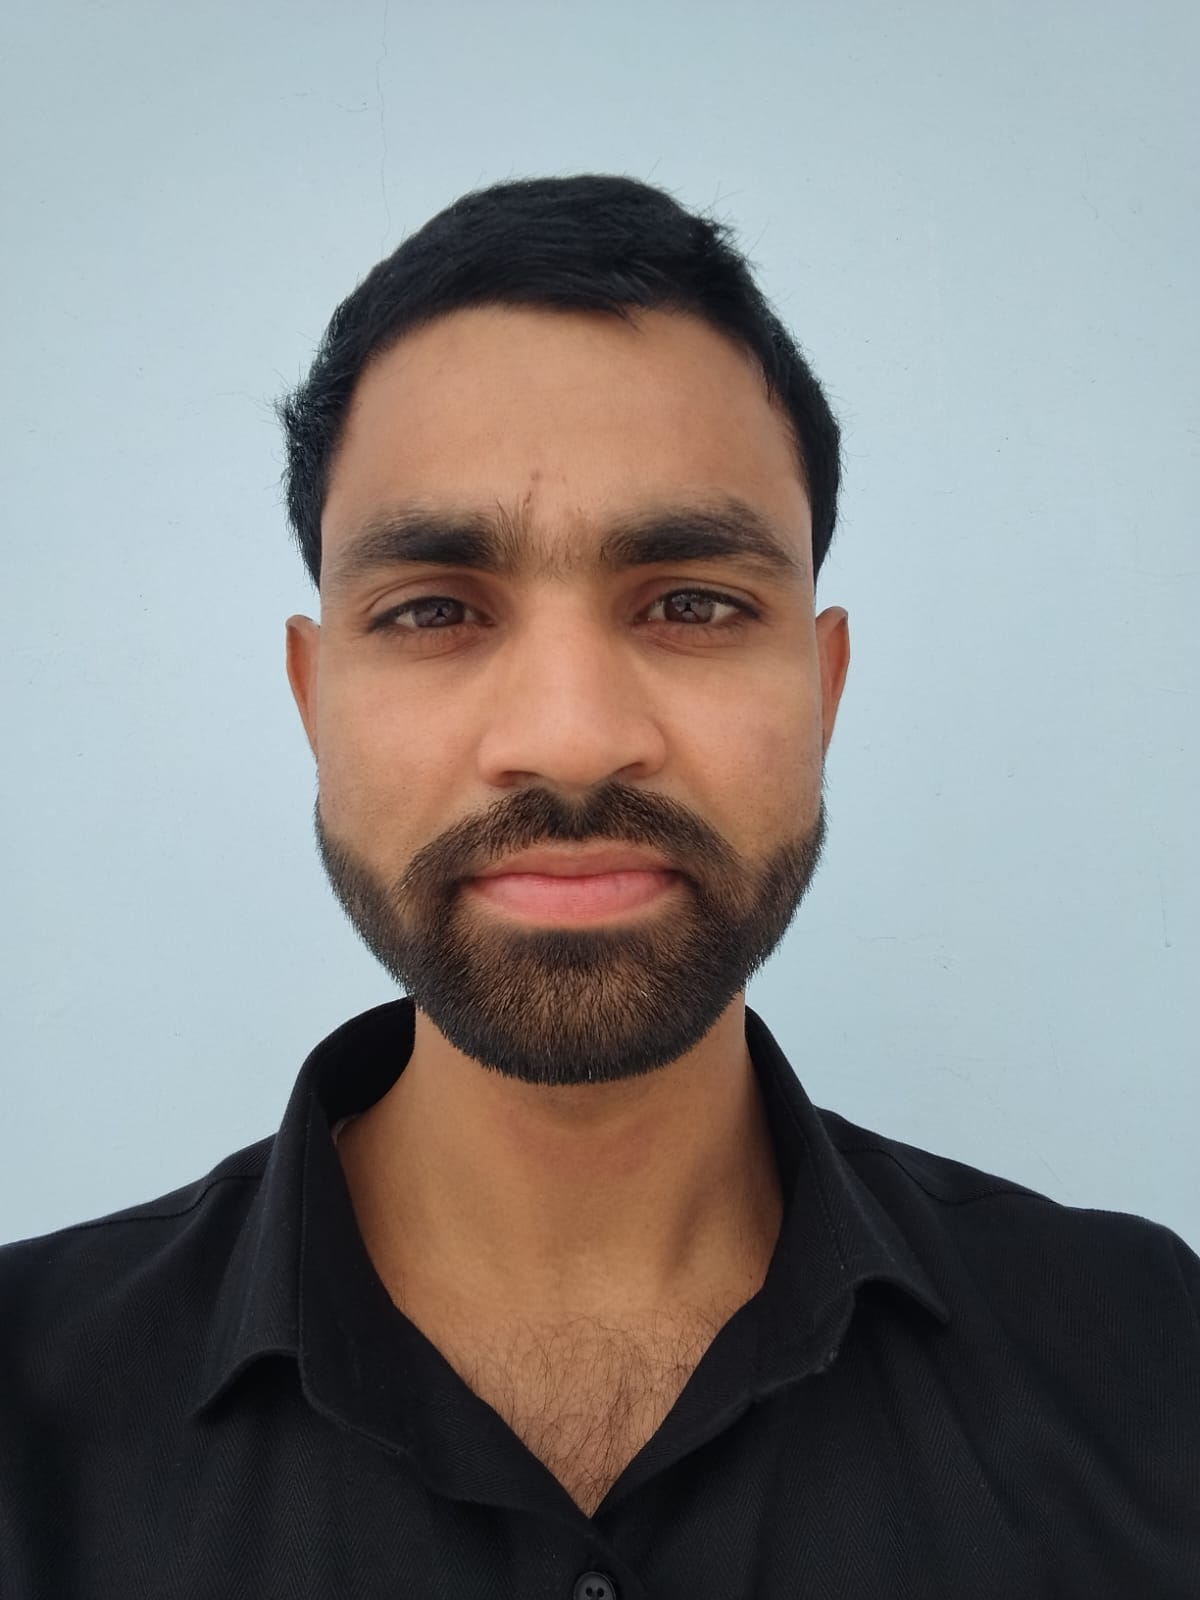

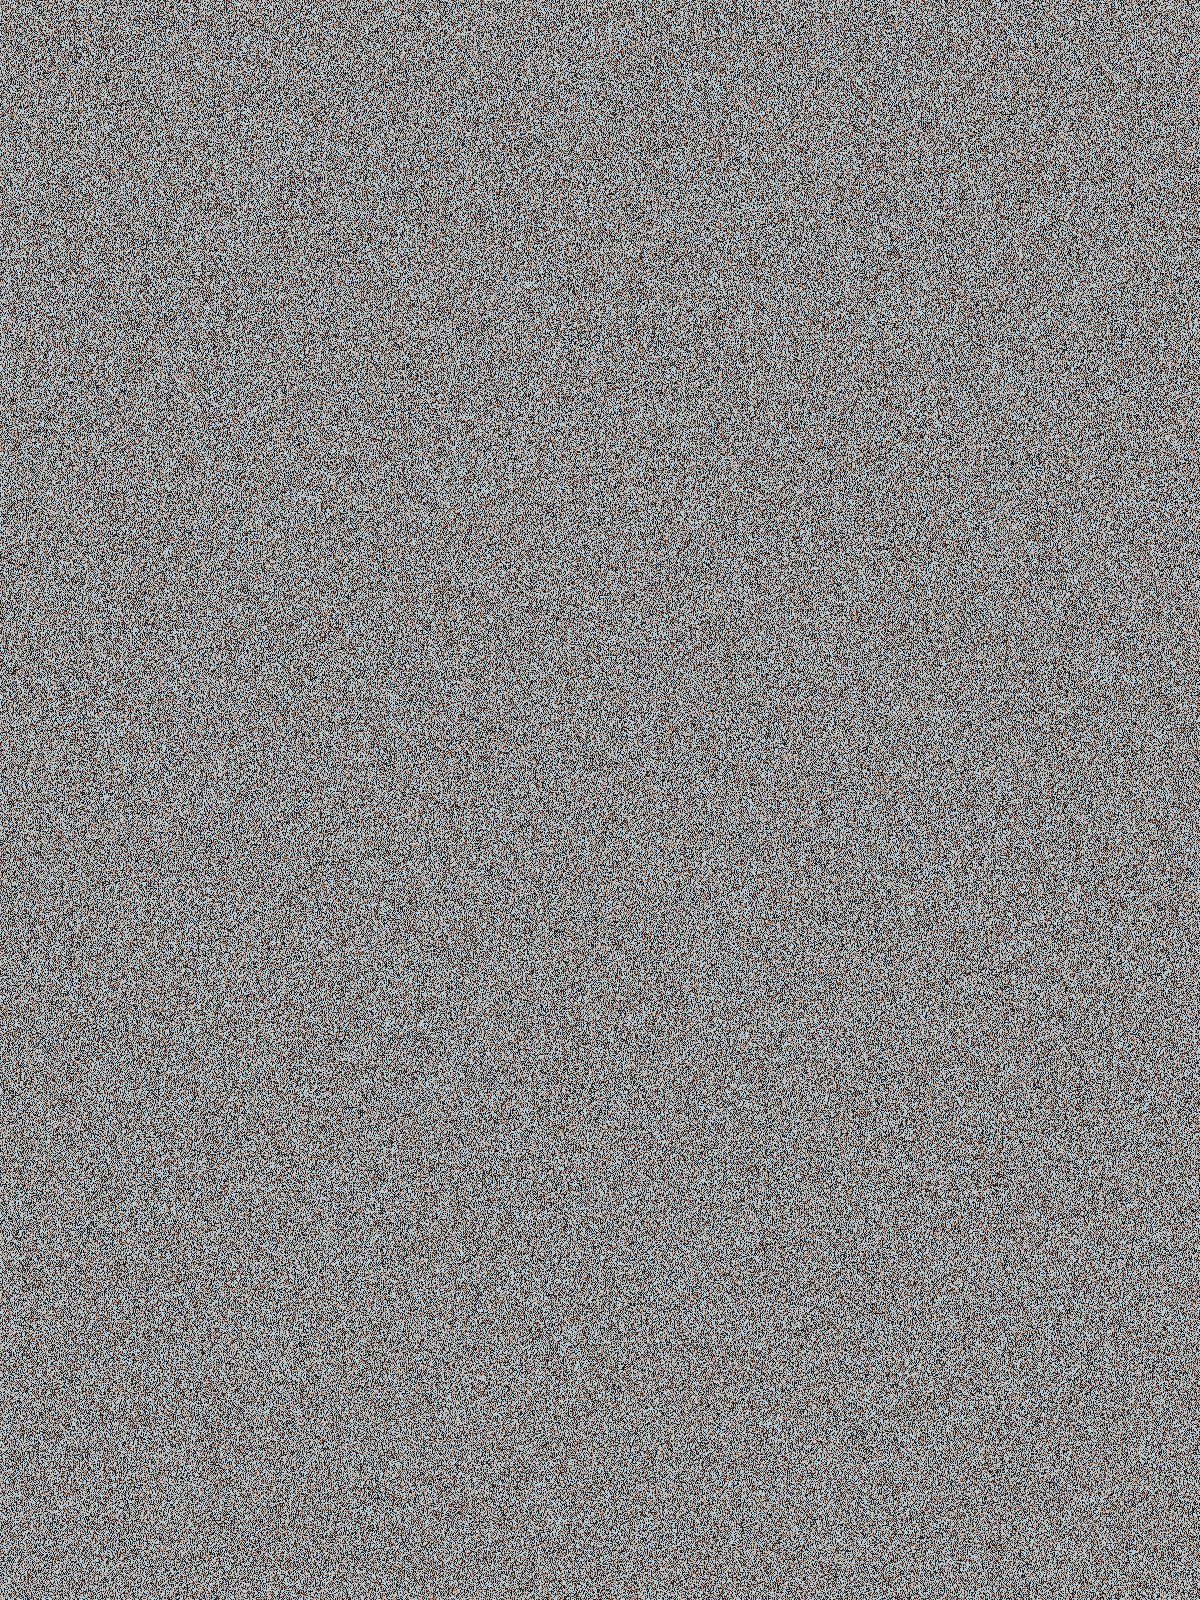

Entropy original: 7.1696
Entropy encrypted: 7.1696
Adj corr original: {'horizontal': 0.9982556520118203, 'vertical': 0.9987521818958636, 'diagonal': 0.997352638677853}
Adj corr encrypted: {'horizontal': -0.18031598820534062, 'vertical': -7.374740990188847e-05, 'diagonal': -8.924970925286446e-05}
NPCR (sensitivity): 99.6560 %
UACI (sensitivity): 33.7920 %
Encryption time (s): 3.3571


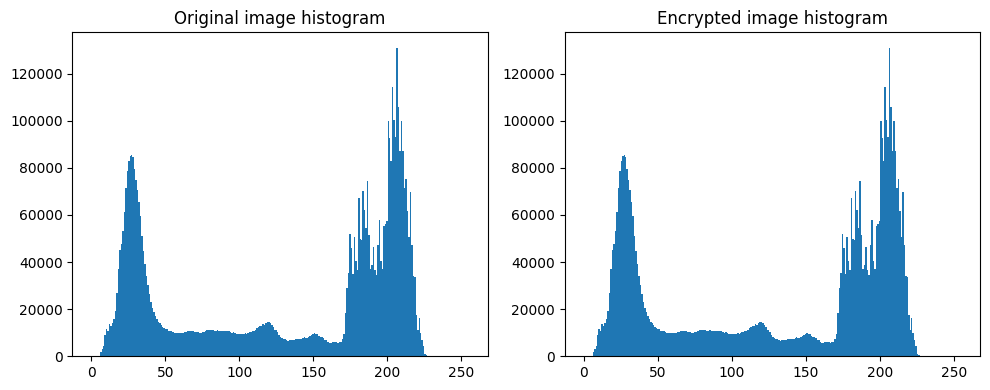

In [ ]:
# Cell 4
from IPython.display import Image, display
import matplotlib.pyplot as plt

# save small PNGs to display
_, buf = cv2.imencode('.png', img); open('orig.png','wb').write(buf.tobytes())
_, buf = cv2.imencode('.png', enc_arr); open('enc.png','wb').write(buf.tobytes())

display(Image('orig.png', width=300))
display(Image('enc.png', width=300))

print("Entropy original:", round(entropy(img),4))
print("Entropy encrypted:", round(entropy(enc_arr),4))
print("Adj corr original:", adjacent_correlation(img))
print("Adj corr encrypted:", adjacent_correlation(enc_arr))
npcr_sens, uaci_sens = analyze_performance(img, password)
print("NPCR (sensitivity):", f"{npcr_sens:.4f} %")
print("UACI (sensitivity):", f"{uaci_sens:.4f} %")
print(f"Encryption time (s): {enc_time:.4f}")

# histograms (original vs encrypted)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Original image histogram"); plt.hist(img.flatten(), bins=256, range=(0,255))
plt.subplot(1,2,2); plt.title("Encrypted image histogram"); plt.hist(enc_arr.flatten(), bins=256, range=(0,255))
plt.tight_layout()
plt.show()


Cell 5 — Upload .cenc to decrypt:


In [ ]:
# Cell 5
from google.colab import files
upl = files.upload()   # select the .cenc you downloaded
cenc_file = list(upl.keys())[0]
print("Uploaded:", cenc_file)
with open(cenc_file, "rb") as f:
    blob = f.read()


Saving WhatsApp Image 2026-04-10 at 10.47.16.jpeg.cenc to WhatsApp Image 2026-04-10 at 10.47.16.jpeg (1).cenc
Uploaded: WhatsApp Image 2026-04-10 at 10.47.16.jpeg (1).cenc


Cell 6 — Unpack .cenc, decrypt (use stored entropy_tag), measure time, save & download:

In [ ]:
# Cell 6
from google.colab import files as gfiles
import time

password = input("Enter decryption password: ").strip()
png_bytes, orig_name, entropy_norm_dec, entropy_tag = unpack_cenc(blob)
print("Original filename:", orig_name)
print("Entropy tag from .cenc:", entropy_tag)

enc_arr_from_cenc = png_bytes_to_array(png_bytes)

t0 = time.time()
dec = decrypt_array(enc_arr_from_cenc, password, entropy_norm_dec, entropy_tag)
t_dec = time.time() - t0
print(f"Decryption time: {t_dec:.4f} seconds")

# save decrypted PNG
dec_name = "decrypted_" + orig_name
_, buf = cv2.imencode('.png', dec)
with open(dec_name, "wb") as f:
    f.write(buf.tobytes())
print("Saved decrypted PNG:", dec_name)

gfiles.download(dec_name)

# keep for verification
dec_arr = dec
dec_time = t_dec


Enter decryption password: 123
Original filename: WhatsApp Image 2026-04-10 at 10.47.16.jpeg
Entropy tag from .cenc: 0.896197193306
Decryption time: 7.3690 seconds
Saved decrypted PNG: decrypted_WhatsApp Image 2026-04-10 at 10.47.16.jpeg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cell 7 — Verify exact match & show final NPCR/UACI & timing:

In [ ]:
# Cell 7
import numpy as np

exact = bool(np.array_equal(img, dec_arr))
print("Decryption exact match:", exact)

print("NPCR original vs decrypted:", f"{npcr(img, dec_arr):.6f} %")
print("UACI original vs decrypted:", f"{uaci(img, dec_arr):.6f} %")

# Already computed sensitivity NPCR/UACI earlier; print again
npcr_sens2, uaci_sens2 = analyze_performance(img, password)
print("NPCR (sensitivity):", f"{npcr_sens2:.4f} %")
print("UACI (sensitivity):", f"{uaci_sens2:.4f} %")
print(f"Encryption time (s): {enc_time:.4f}")
print(f"Decryption time (s): {dec_time:.4f}")


Decryption exact match: True
NPCR original vs decrypted: 0.000000 %
UACI original vs decrypted: 0.000000 %
NPCR (sensitivity): 99.6560 %
UACI (sensitivity): 33.7920 %
Encryption time (s): 3.3571
Decryption time (s): 7.3690
